In [1]:
import pathpyG as pp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
import contextily as cx
import folium

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../data/clean/"))

metadata = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_metadata_all.csv"), dtype={"site_id": str, "huc8": str})

## Visualize streamgague locations

In [2]:
# --- Create geometry from lat/lon ---
geometry = gpd.points_from_xy(metadata["longitude"], metadata["latitude"])

gdf01 = gpd.GeoDataFrame(metadata, geometry=geometry, crs="EPSG:4326")

gdf = pd.concat([gdf01])

# --- Create base map centered on gauges ---
center_lat = gdf["latitude"].mean()
center_lon = gdf["longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    tiles="OpenStreetMap"
)

# --- Add gauge markers for basin 1 ---
fg1 = folium.FeatureGroup(name="Stream gauges 02040101")

for _, row in gdf01.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color="red",
        fill=True,
        fill_color="red",
        popup=f"Site ID: {row['site_id']} \n Site Name: {row['site_name']}"
    ).add_to(fg1)

fg1.add_to(m)

# --- Add layer control ---
folium.LayerControl().add_to(m)

# --- Save interactive HTML map ---
m.save("stream_gauges_map_subbasin.html")

### Static map

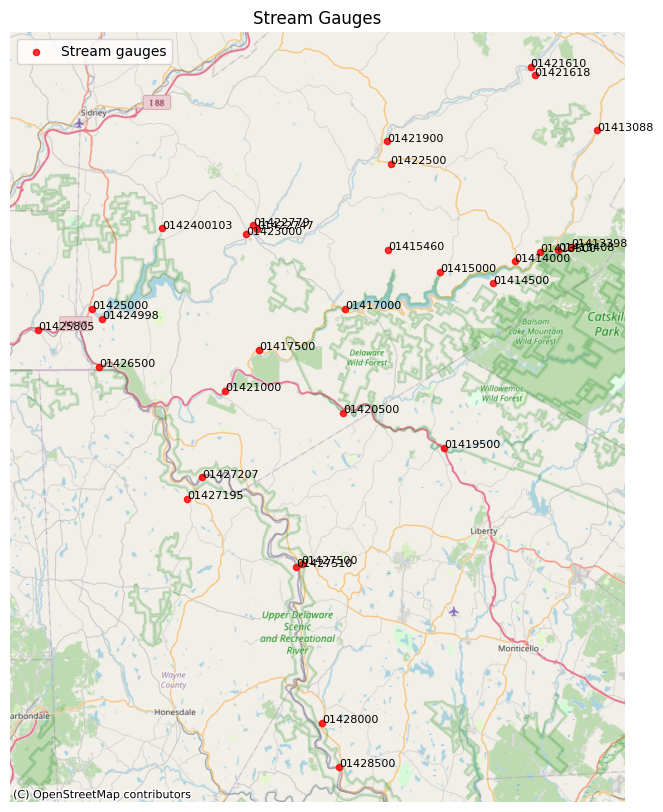

In [3]:
# --- Convert to Web Mercator for basemap ---
gdf = gdf.to_crs(epsg=3857)


# --- Plot ---
fig, ax = plt.subplots(figsize=(10,10))

gdf.plot(
    ax=ax,
    color="red",
    markersize=20,
    alpha=0.8,
    label="Stream gauges"
)

# Add basemap 
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
ax.legend(loc="upper left")
# Add labels
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf["site_id"]):
    ax.text(x, y, str(label),fontsize=8)

plt.title("Stream Gauges")
plt.show()

## Rename sites and create directed graph

In [4]:
# site_dict = {
#     1421610: "site0",
#     1421618: "site1",
#     1421900: "site2",
#     1422500: "site3",
#     1422747: "site4",
#     1422779: "site5",
#     1423000: "site6",
#     142400103: "site7",
#     1424998: "site8",
#     1425000: "site9",
#     1425805: "site10",
#     1426500: "site11",
#     1427195: "site12",
#     1427207: "site13",
#     1427500: "site14",
#     1427510: "site15",
#     1428000: "site16",
#     1428500: "site17",
#     1413088: "site18",
#     1413398: "site19",
#     1413408: "site20",
#     1413500: "site21",
#     1414000: "site22",
#     1414500: "site23",
#     1415000: "site24",
#     1415460: "site25",
#     1417000: "site26",
#     1417500: "site27",
#     1419500: "site28",
#     1420500: "site29",
#     1421000: "site30"
# }

In [5]:
# List of new site names in the order I specified (from upstream > downstream)
site_rename_list = [
    "site0", "site1", "site2", "site3", "site4",
    "site6", "site7", "site9", "site11", "site13",
    "site14", "site15", "site16", "site17", "site5",
    "site10", "site12", "site8",
    "site18", "site19", "site20", "site21", "site22",
    "site23", "site24", "site25", "site26", "site27",
    "site28", "site29", "site30"
]

metadata["site_rename"] = site_rename_list

metadata[['site_id', 'site_name', 'site_rename']]


,site_id,site_name,site_rename
0,01413088,EAST BRANCH DELAWARE RIVER AT ROXBURY NY,site0
1,01413398,BUSH KILL NEAR ARKVILLE NY,site1
2,01413408,DRY BROOK AT ARKVILLE,site2
3,01413500,EAST BRANCH DELAWARE RIVER AT MARGARETVILLE NY,site3
4,01414000,PLATTE KILL AT DUNRAVEN NY,site4
5,01414500,MILL BROOK NEAR DUNRAVEN NY,site6
6,01415000,TREMPER KILL NEAR ANDES NY,site7
7,01415460,TERRY CLOVE KILL NEAR DE LANCEY NY,site9
8,01417000,EAST BRANCH DELAWARE RIVER AT DOWNSVILLE NY,site11
9,01417500,EAST BRANCH DELAWARE RIVER AT HARVARD NY,site13


In [6]:
graph_edges = [("site0", "site2"), 
              ("site1", "site2"),
              ("site2", "site6"),
              ("site3", "site6"),
              ("site4", "site6"),
              ("site5", "site6"),
              ("site6", "site8"), #note site 6 and 7 both flow into the reservoir but from differennt brances
              ("site7", "site8"), #note site 8 is after the reservoir
              ("site8", "site9"),
              ("site9", "site11"),
              ("site10", "site11"),
              ("site11", "site13"),
              ("site12", "site13"),
              ("site13", "site15"),
              ("site14", "site15"),
              ("site15", "site17"),
              ("site16", "site17")] 


graph_edges02 = [("site18", "site21"),
              ("site19", "site20"),
              ("site20", "site21"),
              ("site21", "site26"), # NOTE site 26 is th outlet of the Pepcaton reservoir so all these other sites lead to the reservoir
              ("site22", "site26"),
              ("site23", "site26"),
              ("site24", "site26"),
              ("site25", "site26"),
              ("site26", "site27"),
              ("site27", "site30"),
              ("site28", "site29"),
              ("site29", "site30")]


graph_edges_all = graph_edges + graph_edges02 + [("site30", "site13")] # point of connection between the two subbasins

In [7]:
river_network = pp.Graph.from_edge_list(graph_edges_all)

# Adjacency matrix 
A = river_network.sparse_adj_matrix()
# print(A.todense())

## Not sure why the order of the nodes is different than the order of site 1 etc. so issue coloring
group0 = ("site0", "site1", "site2", "site3", "site4", "site5", "site6", "site7", "site8", "site9", "site10", "site11", "site12", "site13", "site14", "site15", "site16", "site17")
group1 = ("site18", "site19", "site20", "site21", "site22", "site23", "site24", "site25", "site26", "site27", "site28", "site29", "site30")
z= []
for i, node in enumerate(river_network.nodes):
    if node in group0:
        z.append(0)
    elif node in group1:
        z.append(1)
# z = np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1])

colors = {0: 'red', 1: 'blue'}
pp.plot(river_network, node_color = [colors[z[river_network.mapping.to_idx(x)]] for x in river_network.nodes], node_label = [x for x in river_network.mapping.node_ids]);

## Adding attributes to nodes

note: All `Node` attributes must be prefixed with `node_`. Just like nodes, `Edge` objects can store arbitrary attributes that we can add as a tensor. The name of the attribute must be prefixed by `edge_`.

### Compute summary statistics

In [1]:
import pathpyG as pp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
import contextily as cx
import folium

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../data/clean/"))

metadata = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_metadata_all.csv"), dtype={"site_id": str, "huc8": str})

# List of new site names in the order I specified (from upstream > downstream)
# Why are these not in order?
site_rename_list = [
    "site0", "site1", "site2", "site3", "site4",
    "site6", "site7", "site9", "site11", "site13",
    "site14", "site15", "site16", "site17", "site5",
    "site10", "site12", "site8",
    "site18", "site19", "site20", "site21", "site22",
    "site23", "site24", "site25", "site26", "site27",
    "site28", "site29", "site30"
]

metadata["site_rename"] = site_rename_list

<Figure size 1200x600 with 0 Axes>

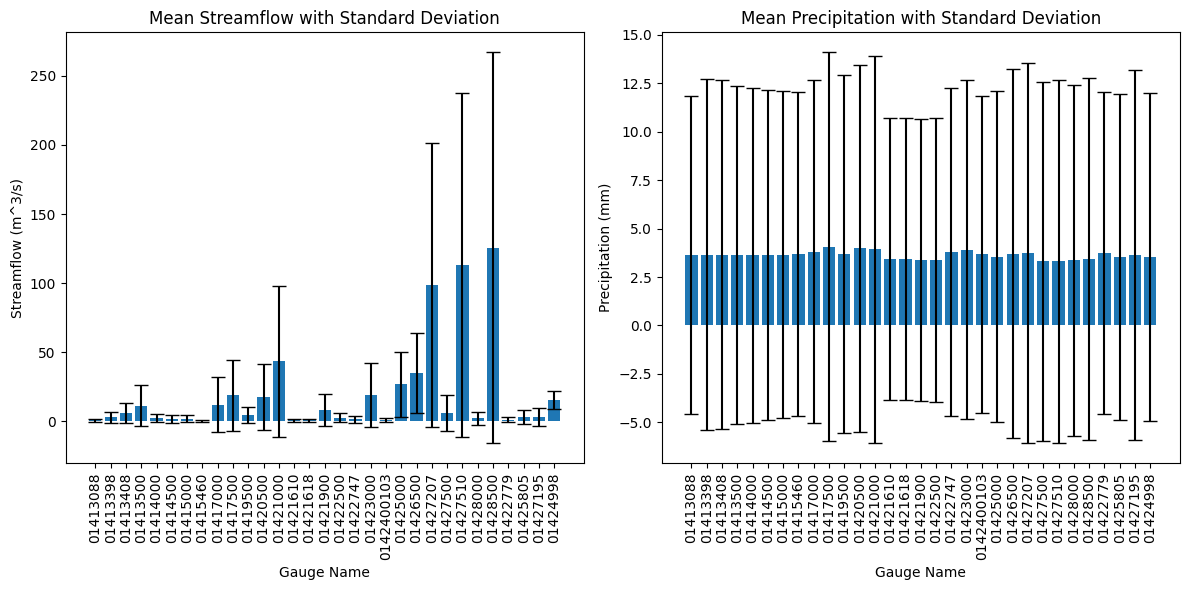

In [2]:
streamflow = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022.csv"), dtype={"site_id": str, "huc8": str})
streamflow.columns = streamflow.columns.astype(str)
precipitation = pd.read_csv(os.path.join(DATA_DIR, "precipitation_wy2022.csv"), dtype={"site_id": str, "huc8": str})
precipitation.columns = precipitation.columns.astype(str)

site_ids = [col for col in streamflow.columns if col != "date"]

mean_streamflow = []
std_streamflow = []
mean_precipitation = []
std_precipitation = []

for site_id in site_ids:
    mean_streamflow.append(streamflow[site_id].mean())
    std_streamflow.append(streamflow[site_id].std())
    mean_precipitation.append(precipitation[site_id].mean())
    std_precipitation.append(precipitation[site_id].std())

plt.figure(figsize=(12, 6))
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].bar(site_ids, mean_streamflow, yerr=std_streamflow, capsize=5)
axes[0].tick_params(axis="x", labelrotation=90)
axes[0].set_title("Mean Streamflow with Standard Deviation")
axes[0].set_ylabel("Streamflow (m^3/s)")
axes[0].set_xlabel("Gauge Name")

axes[1].bar(site_ids, mean_precipitation, yerr=std_precipitation, capsize=5)
axes[1].tick_params(axis="x", labelrotation=90)
axes[1].set_title("Mean Precipitation with Standard Deviation")
axes[1].set_ylabel("Precipitation (mm)")
axes[1].set_xlabel("Gauge Name")
plt.tight_layout()
plt.savefig("figures/mean_std_streamflow_precipitation.png", dpi=300);

In [3]:
# import torch
# river_network.data.node_avgprecip = torch.tensor(mean_precipitation)

graph_edges = [("site0", "site2"), 
              ("site1", "site2"),
              ("site2", "site6"),
              ("site3", "site6"),
              ("site4", "site6"),
              ("site5", "site6"),
              ("site6", "site8"), #note site 6 and 7 both flow into the reservoir but from differennt brances
              ("site7", "site8"), #note site 8 is after the reservoir
              ("site8", "site9"),
              ("site9", "site11"),
              ("site10", "site11"),
              ("site11", "site13"),
              ("site12", "site13"),
              ("site13", "site15"),
              ("site14", "site15"),
              ("site15", "site17"),
              ("site16", "site17")] 


graph_edges02 = [("site18", "site21"),
              ("site19", "site20"),
              ("site20", "site21"),
              ("site21", "site26"), # NOTE site 26 is th outlet of the Pepcaton reservoir so all these other sites lead to the reservoir
              ("site22", "site26"),
              ("site23", "site26"),
              ("site24", "site26"),
              ("site25", "site26"),
              ("site26", "site27"),
              ("site27", "site30"),
              ("site28", "site29"),
              ("site29", "site30")]


graph_edges_all = graph_edges + graph_edges02 + [("site30", "site13")] # point of connection between the two subbasins
river_network = pp.Graph.from_edge_list(graph_edges_all).to_undirected()
A = river_network.sparse_adj_matrix();

### Data Analysis
#### Community detection using simulated annealing
Using the simulated annealing algorithm from assignment 2 to detect clusters and find the optimal number of blocks B.
Because the trivial solution to assign each node its individual cluster and to have B=n is to be avoided, we limit the number of blocks manually to n//2.

In [4]:
from tqdm.notebook import tqdm
from collections import Counter, defaultdict
import scipy as sp

def log(x):
    if x == 0:
        return 0
    else:
        return np.log(x)

def SBM_max_likelihood(z, graph: pp.Graph):
    B = len(set(z))
    C = Counter(z)
    L = 0    
    E = np.zeros((B,B))
    N = np.zeros((B,B))
    
    for k in range(B):
        for l in range(B):
            # calculate possible links
            if k == l:
                N[k,l] = sp.special.binom(C[k], 2)
            else:
                N[k,l]= C[k] * C[l]
            for v,w in graph.edges:
                v_idx = graph.mapping.to_idx(v)
                w_idx = graph.mapping.to_idx(w)
                if v_idx < w_idx and ((z[v_idx] == k and z[w_idx] == l) or (z[v_idx] == l and z[w_idx] == k)):
                    E[k,l] += 1
    M = E / N
    M = np.nan_to_num(M) 
    for k in range(B):
        for l in range(k+1):
            L+= E[k,l] * log(M[k,l]+1e-12) + (N[k,l] - E[k,l]) * log(1-M[k,l]+1e-12)
    # if L<0:
    #     L = np.exp(L)
    # else:
    #     L = np.exp(L)

    return L, M

def SBM_dc_likelihood(z, n: pp.Graph):

    m = n.n
    B = len(set(z))

    L = 0
    
    # E[k,l] counts how many links exist between nodes in block k and block l
    E = np.zeros((B,B))
    for k in range(B):
        for l in range(B):
            # count number of links
            for v,w in n.edges:
                v_idx = n.mapping.to_idx(v)
                w_idx = n.mapping.to_idx(w)
                if v_idx < w_idx and ((z[v_idx] == k and z[w_idx] == l) or (z[v_idx] == l and z[w_idx] == k)):
                    E[k,l] += 1
            if k == l:
                E[k,l] = 2*E[k,l]

    # kappa[k] counts sum of degrees within block k
    kappa = defaultdict(lambda: 0)
    
    for k in range(B):
        for v in n.nodes:
            if (z[n.mapping.to_idx(v)] == k):
                kappa[k] += n.degrees()[str(v)]

    for r in range(B):
        for s in range(r+1):
            L+= E[r,s] * log(E[r,s]/(kappa[r]*kappa[s])+1e-12)

    return L, None

def simulated_annealing_find_B(graph: pp.Graph, cooling_slowness = 100, changes_per_iter=1, iterations=1000):
    temperatures = []
    likelihoods = []

    n = graph.n
    z = np.zeros(n, dtype=int)
    curr_best_l, M = SBM_max_likelihood(z, graph)

    for i in tqdm(range(iterations)):

        t = (1+cooling_slowness)/(i+1+cooling_slowness)
        z_copy = z.copy()

        if (np.random.rand() < 0.5 or len(set(z)) == 1) and len(set(z)) < n//4:
            block_to_split = np.random.choice(list(set(z)))
            print("Splitting block:", block_to_split)
            members_of_block_to_split = np.where(z_copy == block_to_split)[0]
            if len(members_of_block_to_split) <= 1:
                continue
            np.random.shuffle(members_of_block_to_split)
            for node in members_of_block_to_split[:len(members_of_block_to_split)//2]:
                z_copy[node] = max(z) + 1
        else:
            block_to_merge_1, block_to_merge_2 = np.random.choice(list(set(z)), size=2, replace=False)
            print("Merging blocks:", block_to_merge_1, "and", block_to_merge_2)
            z_copy[z_copy == block_to_merge_2] = block_to_merge_1

        current_labels = np.unique(z_copy)
        z_copy_renorm = np.zeros(len(z_copy), dtype=int)
        for idx, label in enumerate(current_labels):
            z_copy_renorm[z_copy == label] = idx
        print("new z = ", z_copy) 
        

        l_new, M = SBM_max_likelihood(z_copy_renorm, graph)
        print("Iteration:", i, "Current best likelihood:", curr_best_l, "New likelihood:", l_new)
        if l_new > curr_best_l or np.random.random() <= np.exp(-(log(curr_best_l+1e-12)-log(l_new+1e-12))/t):
            z = z_copy_renorm
            curr_best_l = l_new

        likelihoods.append(l_new)
        temperatures.append(t)

    return z, curr_best_l

def simulated_annealing(network: pp.Graph, B, cooling_slowness = 5000, changes_per_iter=1, iterations=1000):
    likelihoods = []
    n = network.n
    z = np.zeros(n, dtype=int)
    for i in range(n):
        z[i] = int(np.random.randint(B))
    l, m = SBM_max_likelihood(z, network)
    #l, m = SBM_dc_likelihood(z, network)

    z_best = z.copy()
    l_best = l

    # we output the cooling temperatures to inspect the cooling schedule
    temperatures = []

    for i in tqdm(range(iterations)):

        t = (1+cooling_slowness)/(i+1+cooling_slowness)

        # randomly change community of random node
        z_new = z.copy()

        for j in range(changes_per_iter):
            node_idx = np.random.choice(n)
            z_new[node_idx] = (z[node_idx] + np.random.randint(1, B)) % B #np.random.choice(B)
        l_new, m_new = SBM_max_likelihood(z_new, network)
        #l_new, m_new = SBM_dc_likelihood(z_new, network)
        if l_new >= l:
            z = z_new
            l = l_new
            if l_new > l_best:       # only update best if truly the best seen
                z_best = z_new.copy()
                l_best = l_new
        elif np.random.random() <= np.exp(-(l-l_new)/t):
            z = z_new
            l = l_new

        likelihoods.append(np.exp(l))
        temperatures.append(t)
    return z_best, l_best, likelihoods, temperatures

np.random.seed(42)
z1, l_best, curr_best_l1, _ = simulated_annealing(river_network, 2, iterations=50000)
print("When fixing B to 3 the optimal z and likelihood as found through simulated annealing are: \n", z1, l_best)

z2, curr_best_l2 = simulated_annealing_find_B(river_network, iterations=10000)
print("finding B algorithm results, z and likelihoods:", z2, curr_best_l2)


  0%|          | 0/50000 [00:00<?, ?it/s]

When fixing B to 3 the optimal z and likelihood as found through simulated annealing are: 
 [0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 0] -93.31168768653586


  0%|          | 0/10000 [00:00<?, ?it/s]

Splitting block: 0
new z =  [0 0 0 1 1 1 0 0 1 1 0 0 0 0 1 0 0 1 1 1 1 0 1 0 0 0 1 1 0 1 1]
Iteration: 0 Current best likelihood: -111.23594862374843 New likelihood: -108.8666468420254
Merging blocks: 1 and 0
new z =  [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Iteration: 1 Current best likelihood: -108.8666468420254 New likelihood: -111.23594862374843
Merging blocks: 0 and 1
new z =  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Iteration: 2 Current best likelihood: -108.8666468420254 New likelihood: -111.23594862374843
Splitting block: 0
new z =  [0 0 2 1 1 1 0 2 1 1 0 2 2 2 1 0 2 1 1 1 1 2 1 0 2 0 1 1 0 1 1]
Iteration: 3 Current best likelihood: -108.8666468420254 New likelihood: -106.84772766534756
Splitting block: 0
new z =  [3 3 2 1 1 1 0 2 1 1 0 2 2 2 1 0 2 1 1 1 1 2 1 0 2 3 1 1 3 1 1]
Iteration: 4 Current best likelihood: -106.84772766534756 New likelihood: -106.56460609142823
Splitting block: 0
new z =  [3 3 2 1 1 1 0 2 1 1 4 2 2 2 1 0 2 1

/tmp/ipykernel_53357/3620211752.py:9: RuntimeWarning: invalid value encountered in log
  return np.log(x)
/tmp/ipykernel_53357/3620211752.py:30: RuntimeWarning: invalid value encountered in divide
  M = E / N


 55 Current best likelihood: -101.09330611682712 New likelihood: -102.08791527860744
Merging blocks: 4 and 6
new z =  [3 3 2 1 4 4 5 2 1 1 4 2 2 2 4 0 2 4 4 1 1 2 1 4 2 3 4 1 3 1 4]
Iteration: 56 Current best likelihood: -101.09330611682712 New likelihood: -102.24315283450866
Merging blocks: 1 and 3
new z =  [1 1 2 1 6 6 5 2 1 1 4 2 2 2 6 0 2 6 6 1 1 2 1 4 2 1 6 1 1 1 6]
Iteration: 57 Current best likelihood: -101.09330611682712 New likelihood: -105.9177611719044
Merging blocks: 4 and 3
new z =  [4 4 2 1 6 6 5 2 1 1 4 2 2 2 6 0 2 6 6 1 1 2 1 4 2 4 6 1 4 1 6]
Iteration: 58 Current best likelihood: -101.09330611682712 New likelihood: -103.04903122754813
Merging blocks: 0 and 2
new z =  [3 3 0 1 6 6 5 0 1 1 4 0 0 0 6 0 0 6 6 1 1 0 1 4 0 3 6 1 3 1 6]
Iteration: 59 Current best likelihood: -101.09330611682712 New likelihood: -102.08791527860744
Merging blocks: 4 and 5
new z =  [3 3 2 1 6 6 4 2 1 1 4 2 2 2 6 0 2 6 6 1 1 2 1 4 2 3 6 1 3 1 6]
Iteration: 60 Current best likelihood: -101.0933061

In [5]:
#pp.config['visualisation']['default_backend'] = 'matplotlib'
group0 = ("site0", "site1", "site2", "site3", "site4", "site5", "site6", "site7", "site8", "site9", "site10", "site11", "site12", "site13", "site14", "site15", "site16", "site17")
group1 = ("site18", "site19", "site20", "site21", "site22", "site23", "site24", "site25", "site26", "site27", "site28", "site29", "site30")
our_z= []
for i, node in enumerate(river_network.nodes):
    if node in group0:
        our_z.append(0)
    elif node in group1:
        our_z.append(1)
our_likelihood = SBM_max_likelihood(our_z, river_network)
print("our_likelihood = ", our_likelihood)

community_ids1 = sorted(set(z1))
cmap1 = plt.cm.get_cmap("tab10", len(community_ids1))

color_dict1 = {
    community_id: cmap1(i)
    for i, community_id in enumerate(community_ids1)
}
pp.plot(river_network, node_color = [color_dict1[z1[river_network.mapping.to_idx(x)]] for x in river_network.nodes], node_label = [x for x in river_network.mapping.node_ids]);

community_ids2 = sorted(set(z2))
cmap2 = plt.cm.get_cmap("tab10", len(community_ids2))

color_dict2 = {
    community_id: cmap2(i)
    for i, community_id in enumerate(community_ids2)
}

pp.plot(river_network, node_color = [color_dict2[z2[river_network.mapping.to_idx(x)]] for x in river_network.nodes], node_label = [x for x in river_network.mapping.node_ids]);


our_likelihood =  (np.float64(-93.31168768653586), array([[0.11111111, 0.0042735 ],
       [0.0042735 , 0.15384615]]))


/tmp/ipykernel_53357/566368898.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = plt.cm.get_cmap("tab10", len(community_ids1))


/tmp/ipykernel_53357/566368898.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = plt.cm.get_cmap("tab10", len(community_ids2))


##### Observations
Simulated annealing is not feasible to detect the community structure of our graph - even though 30 stream gauges does not appear prohibitively large, this number of stream gauges in our network is too big for a heuristic like simulated annealing to reliably find the optimum that we assign by hand.

#### Random Walker for cluster detection
Imagine the river network as undirected for this application, to allow a random walker to walk downstream as well as upstream.

In [2]:
import pathpyG as pp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
import contextily as cx
import folium

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../data/clean/"))

metadata = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_metadata_all.csv"), dtype={"site_id": str, "huc8": str})

# List of new site names in the order I specified (from upstream > downstream)
# Why are these not in order?
site_rename_list = [
    "site0", "site1", "site2", "site3", "site4",
    "site6", "site7", "site9", "site11", "site13",
    "site14", "site15", "site16", "site17", "site5",
    "site10", "site12", "site8",
    "site18", "site19", "site20", "site21", "site22",
    "site23", "site24", "site25", "site26", "site27",
    "site28", "site29", "site30"
]

metadata["site_rename"] = site_rename_list

# import torch
# river_network.data.node_avgprecip = torch.tensor(mean_precipitation)

graph_edges = [("site0", "site2"), 
              ("site1", "site2"),
              ("site2", "site6"),
              ("site3", "site6"),
              ("site4", "site6"),
              ("site5", "site6"),
              ("site6", "site8"), #note site 6 and 7 both flow into the reservoir but from differennt brances
              ("site7", "site8"), #note site 8 is after the reservoir
              ("site8", "site9"),
              ("site9", "site11"),
              ("site10", "site11"),
              ("site11", "site13"),
              ("site12", "site13"),
              ("site13", "site15"),
              ("site14", "site15"),
              ("site15", "site17"),
              ("site16", "site17")] 


graph_edges02 = [("site18", "site21"),
              ("site19", "site20"),
              ("site20", "site21"),
              ("site21", "site26"), # NOTE site 26 is th outlet of the Pepcaton reservoir so all these other sites lead to the reservoir
              ("site22", "site26"),
              ("site23", "site26"),
              ("site24", "site26"),
              ("site25", "site26"),
              ("site26", "site27"),
              ("site27", "site30"),
              ("site28", "site29"),
              ("site29", "site30")]


graph_edges_all = graph_edges + graph_edges02 + [("site30", "site13")] # point of connection between the two subbasins
river_network = pp.Graph.from_edge_list(graph_edges_all).to_undirected()
A = river_network.sparse_adj_matrix();

In [3]:
# Functions reused from Notebook 06_04_InfoMap 

from collections import defaultdict
import seaborn as sns

def log2_0(x):
    return 0 if x == 0 else np.log2(x)

def minimal_code_length(p, module_map):
    module_to_nodes = defaultdict(list)
    for node in module_map:
        module_to_nodes[module_map[node]].append(node)
    module_labels = set(module_map.values())
    transitions = len(p) - 1
    within_prob = defaultdict(lambda: 0.0)
    exit_prob = defaultdict(lambda: 0.0)
    node_prob = defaultdict(lambda: 0.0)
    current_module = module_map[p[0]]
    node_prob[p[0]] += 1
    exit_prob[current_module] += 1
    for x in p[1:]:
        node_prob[x] += 1
        if module_map[x] == current_module:
            within_prob[current_module] += 1
        else:
            exit_prob[current_module] += 1
            current_module = module_map[x]
    for i in module_labels:
        exit_prob[i] = exit_prob[i] / (transitions + 1)
        within_prob[i] = within_prob[i] / transitions
    q = sum(exit_prob.values())
    for n in module_map:
        node_prob[n] = node_prob[n] / (transitions + 1)
    S = 0.0
    H_Q = 0.0
    for m in module_labels:
        D = sum(node_prob[w] for w in module_to_nodes[m])
        H_Q += -D * log2_0(D)
        H_Pi = sum(-(node_prob[w] / D) * log2_0(node_prob[w] / D) for w in module_to_nodes[m])
        S += D * H_Pi
    return q * H_Q + S

def merge(C, x, y):
    D = {}
    for i in C:
        if C[i] == x:
            D[i] = y
        else:
            D[i] = C[i]
    return D

def find_communities_walk(network, walk, iterations=100):
    C = {}
    c = 0
    for n in network.nodes:
        C[n] = c
        c += 1
    dl = minimal_code_length(walk, C)
    communities = set(C.values())
    dl_vals = [dl]
    for _ in range(iterations):
        if len(communities) > 1:
            ind = np.random.choice(len(walk) - 2)
            x, y = C[walk[ind]], C[walk[ind + 1]]
            dl_new = minimal_code_length(walk, merge(C, x, y))
            if dl_new < dl:
                C = merge(C, x, y)
                communities = set(C.values())
                dl = dl_new
            dl_vals.append(dl)
    return C, dl_vals

# New function to generate random walks on the graph, which we can then use to find communities using the above functions.
def random_walk(network, steps, seed=None):
    neighbours = defaultdict(list)
    for v, w in network.edges:
        neighbours[v].append(w)
        neighbours[w].append(v)
    rng = np.random.default_rng(seed)
    start = rng.choice(list(network.nodes))
    walk = [start]
    for _ in range(steps):
        current = walk[-1]
        walk.append(rng.choice(neighbours[current]))
    return walk

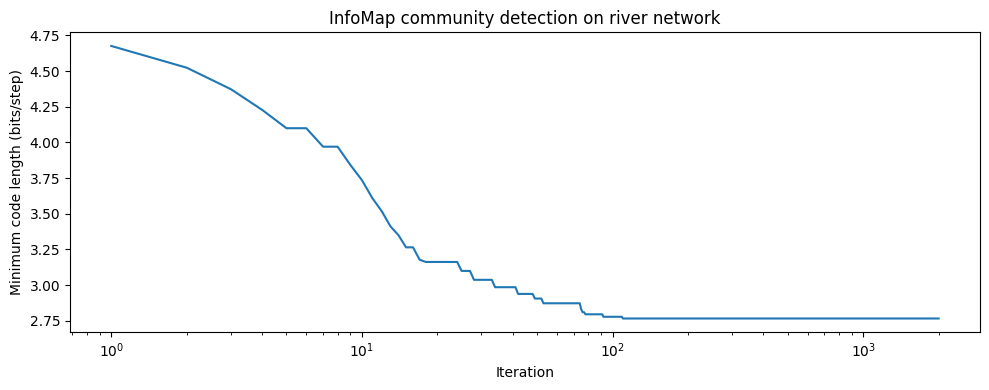

Detected 6 communities


In [4]:
# ── Run random walk and detect communities ────────────────────────────────────

# Build neighbour lookup from the edge list
neighbours = defaultdict(list)
for v, w in river_network.edges:
    neighbours[v].append(w)
    neighbours[w].append(v)   # already undirected, but harmless

def random_walk(network, steps, seed=None):
    rng = np.random.default_rng(seed)
    start = rng.choice(list(network.nodes))
    walk = [start]
    for _ in range(steps):
        current = walk[-1]
        walk.append(rng.choice(neighbours[current]))
    return walk

walk = random_walk(river_network, steps=100000, seed=42)

# Find communities that best compress the walk sequence
C, dl_vals = find_communities_walk(river_network, walk, iterations=2000)

# Plot description length convergence
plt.figure(figsize=(10, 4))
plt.semilogx(range(1, len(dl_vals) + 1), dl_vals)
plt.xlabel("Iteration")
plt.ylabel("Minimum code length (bits/step)")
plt.title("InfoMap community detection on river network")
plt.tight_layout()
plt.show()

# Remap arbitrary community IDs to sequential integers 0, 1, 2, ...
community_ids = sorted(set(C.values()))
remap = {old: new for new, old in enumerate(community_ids)}
colors = sns.color_palette("Set1", len(community_ids)).as_hex()

node_colors = [colors[remap[C[v]]] for v in river_network.nodes]
print(f"Detected {len(community_ids)} communities")
pp.plot(river_network, node_color=node_colors,
        node_label=[v for v in river_network.mapping.node_ids])

I can see that it detects somewhat meaningful communities, but more than anticipated - That is probably because the InfoMap algorithm does not like larger communities, as that takes away the advantage of reduced code length.

Next: Fix that the seed does not work - is not reproducible 